In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("SMSSpamCollection.txt", sep="\t", names=["label", "message"])
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.describe()

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [4]:
df.groupby("label").describe()

message                                                               
        count unique                                                top freq
label                                                                       
ham      4825   4516                             Sorry, I'll call later   30
spam      747    653  Please call our customer service representativ...    4

In [5]:
df["length"] = df["message"].apply(len)
df.head()

,label,message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


<Axes: ylabel='Frequency'>

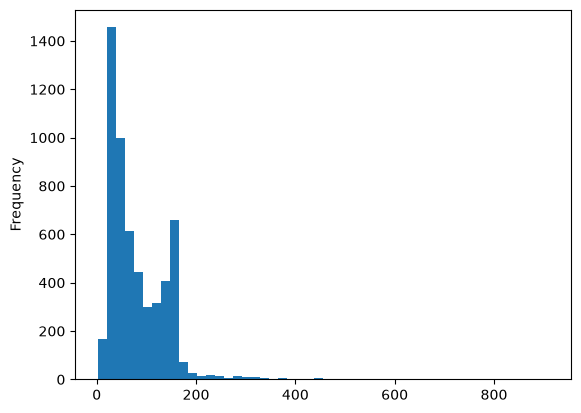

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

df["length"].plot(bins=50, kind="hist")

In [7]:
df.length.describe()

count    5572.000000
mean       80.489950
std        59.942907
min         2.000000
25%        36.000000
50%        62.000000
75%       122.000000
max       910.000000
Name: length, dtype: float64

array([<Axes: title={'center': 'ham'}>, <Axes: title={'center': 'spam'}>],
      dtype=object)

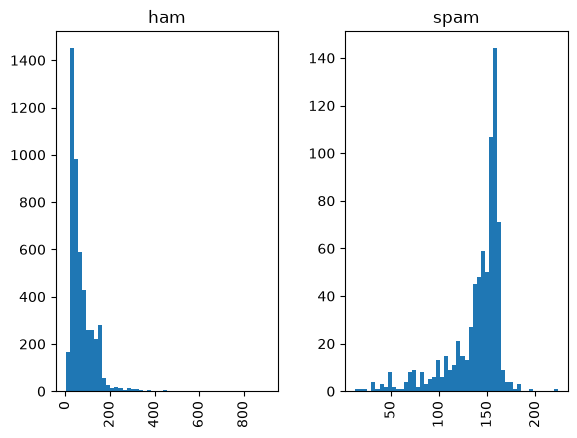

In [8]:
df.hist(column="length", by="label", bins=50)

In [9]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
stopwords.words('english')[0:10] # Show some stop words

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']

In [10]:
import string

def tokenisation(text):
    nopunc = [char for char in text if char not in string.punctuation]
    nopunc = "".join(nopunc)

    return [word for word in nopunc.split() if word.lower() not in stopwords.words("english")]

In [11]:
df["message"].head(5).apply(tokenisation)

0    [Go, jurong, point, crazy, Available, bugis, n...
1                       [Ok, lar, Joking, wif, u, oni]
2    [Free, entry, 2, wkly, comp, win, FA, Cup, fin...
3        [U, dun, say, early, hor, U, c, already, say]
4    [Nah, dont, think, goes, usf, lives, around, t...
Name: message, dtype: object

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

bow_transformer = CountVectorizer(analyzer=tokenisation).fit(df["message"])
df_bow = bow_transformer.transform(df["message"])

In [14]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf_transformer = TfidfTransformer().fit(df_bow)
df_tfidf = tfidf_transformer.transform(df_bow)

In [15]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB().fit(df_tfidf, df["label"])

In [16]:
all_predictions = model.predict(df_tfidf)

from sklearn.metrics import classification_report
print (classification_report(df['label'], all_predictions))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99      4825
        spam       1.00      0.85      0.92       747

    accuracy                           0.98      5572
   macro avg       0.99      0.92      0.95      5572
weighted avg       0.98      0.98      0.98      5572



In [17]:
from sklearn.model_selection import train_test_split

msg_train, msg_test, label_train, label_test = \
train_test_split(df['message'], df['label'], test_size=0.2, random_state=101)


In [18]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('bow', CountVectorizer(analyzer=tokenisation)),  # strings to token integer counts
    ('tfidf', TfidfTransformer()),  # integer counts to weighted TF-IDF scores
    ('classifier', MultinomialNB()),  # train on TF-IDF vectors w/ Naive Bayes classifier
])

pipeline.fit(msg_train,label_train)
predictions = pipeline.predict(msg_test)

print(classification_report(predictions,label_test))

              precision    recall  f1-score   support

         ham       1.00      0.96      0.98      1026
        spam       0.66      1.00      0.79        89

    accuracy                           0.96      1115
   macro avg       0.83      0.98      0.89      1115
weighted avg       0.97      0.96      0.96      1115

